# Comparison of different regression models

On the diabetes dataset (scikit-learn), different lienar regression models are compared with non-linear models. Discuss the impact of the different loss functions for ``Lasso``, ``Ridge`` and ``ElasticNet``.

Discuss model efficiency and interpretation of various metrics.

On the data: The diabetes dataset is a classic "toy" dataset for regression benchmarks. It includes physiological features such as the age, bmi or some blood serum values (s1 - s6), all features are z-scaled. The target is a metric for the progression of the disease.


In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.shape)
X.head()

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# alpha (regularisation parameter in the loss function to penalise coefficients)
# hyperparameters on linear model will be optimised later
lin_models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha= ridge.alpha_),
    "Lasso": Lasso(alpha= lasso.alpha_),
    "ElasticNet": ElasticNet(alpha = elastic.alpha_, l1_ratio=0.5)
}

# hyperparameters for non-linear methods as suggested by Copilot
non_lin_models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        bootstrap=True,
        random_state=42
        ),
    "HistGB": HistGradientBoostingRegressor(     
        learning_rate=0.05,
        max_depth=5,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        max_bins=255,
        early_stopping=True,
        random_state=42
        ),
    "SVR": SVR(    
        kernel="rbf",
        C=10,
        gamma="scale",
        epsilon=0.1
        )
}
models = {**lin_models, **non_lin_models}
#models = lin_models | non_lin_models # concatenation of two dicionaries

In [14]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

results_list = []

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - t0
    y_pred = model.predict(X_test)

    results = {
        "model": name,
        "test_RMSE": np.sqrt(mean_squared_error (y_test, y_pred)),
        "test_MAE": mean_absolute_error(y_test, y_pred),
        "test_R2": r2_score(y_test, y_pred),
        "fit_time_s": fit_time
    }
    results_list.append(results)

res_df = pd.DataFrame(results_list).sort_values("test_RMSE")
res_df

,model,test_RMSE,test_MAE,test_R2,fit_time_s
6,SVR,51.766236,41.243197,0.494212,0.006427
2,Lasso,52.917509,42.791794,0.471464,0.001321
5,HistGB,53.158562,43.494583,0.466638,0.301358
1,Ridge,53.446112,42.996932,0.460852,0.002852
4,RandomForest,53.739698,43.535449,0.454913,0.211151
0,Linear,53.853446,42.794095,0.452603,0.008840
3,ElasticNet,54.838504,45.483576,0.432394,0.000942


In [15]:
# investigate the linear model weights / coefficients

coef_df = pd.DataFrame({
    name: model.fit(X_train, y_train).coef_
    for name, model in lin_models.items()
}, index=X.columns)

coef_df

,Linear,Ridge,Lasso,ElasticNet
age,37.904021,42.855670,0.000000,45.336014
sex,-241.964362,-205.494319,-168.165267,-91.895764
bmi,542.428759,505.089033,554.134694,321.545100
bp,347.703844,317.093205,311.629705,216.814585
s1,-931.488846,-108.500262,-101.862897,-8.332174
s2,518.062277,-86.236733,-0.000000,-38.891342
s3,163.419983,-190.363180,-235.137459,-155.029128
s4,275.317902,151.707086,0.000000,123.754690
s5,736.198859,392.289319,460.585713,251.098588
s6,48.670657,79.908177,36.922057,113.618569


Lasso eleimmates some coefficeients for us aka put to 0
Ridge cant put any coeffiecient to 0 casue of the square 

In [16]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

ridge = RidgeCV(alphas=[0.1, 1, 10])
lasso = LassoCV(cv=5)
elastic = ElasticNetCV(cv=5)

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
elastic.fit(X_train, y_train)

print("Best Ridge alpha:", ridge.alpha_)
print("Best Lasso alpha:", lasso.alpha_)
print("Best ElasticNet alpha:", elastic.alpha_)

Best Ridge alpha: 0.1
Best Lasso alpha: 0.07813983904476522
Best ElasticNet alpha: 0.004450901287065835


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = lin_models["Lasso"].predict(X_test)

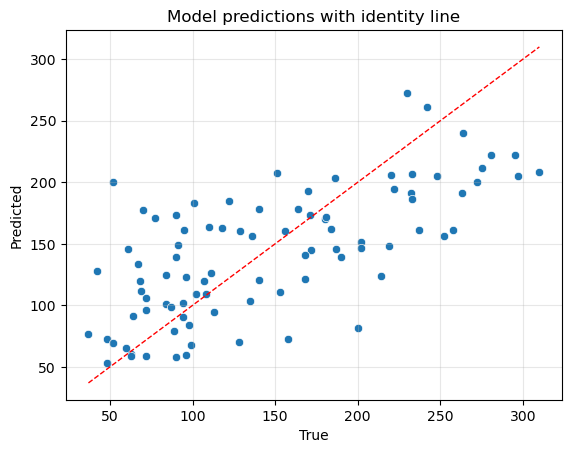

In [18]:
sns.scatterplot(x=y_test, y=y_pred)

# Identity line

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", lw=1)

plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Model predictions with identity line")
plt.grid(alpha=0.3)
plt.show()
